In [7]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.table import Table
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

import matplotlib.pyplot as plt

# Matplotlib configuration
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,           
    'ytick.right': True,         
    'xtick.minor.visible': True, 
    'ytick.minor.visible': True, 
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Pandas configuration
pd.set_option('display.max_columns', None)

# Paths configuration
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']
MAINPATH =  "/Users/jonginpark/sohnix/Research_Archive/2026/Park2026b-MACH-SMF"

%config InlineBackend.figure_format = 'retina'

In [8]:
import pandas as pd
import numpy as np
import emcee
from tqdm import tqdm

# --- Load data ---
field_smf_total = pd.read_csv('./FieldSMF_total.csv')
field_smf_starforming = pd.read_csv('./FieldSMF_starforming.csv')
field_smf_quiescent = pd.read_csv('./FieldSMF_quiescent.csv')

# --- Schechter function ---
def schechter_1D_SMF(M, phi_0, M_star, alpha):
    return np.log(10) * phi_0 * (10 ** ((1 + alpha) * -(M_star - M))) * np.exp(-10 ** -(M_star - M))

# --- Log-likelihood ---
def log_likelihood(theta, x, y, yerr):
    phi_0, M_star, alpha = theta
    model = schechter_1D_SMF(x, phi_0, M_star, alpha)
    return -0.5 * np.sum(((y - model) / yerr) ** 2)

# --- Log-prior ---
def log_prior(theta):
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 1e4 and 8 < M_star < 13 and -2 < alpha < 1:
        return 0.0
    return -np.inf

# --- Log-posterior ---
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    return lp + log_likelihood(theta, x, y, yerr) if np.isfinite(lp) else -np.inf

# --- Run MCMC with hyperparameters ---
def run_mcmc_with_progress(df, label, nwalkers=32, nburn=300, nsteps=1000):
    x = df['logM'].values
    y = df['phi_Mpc-3_dex-1'].values
    yerr = 0.5 * (df['phi_err_low'].values + df['phi_err_up'].values)

    ndim = 3
    initial = np.array([1e-4, 10.7, -1.0])
    pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))

    # Burn-in
    for _ in tqdm(range(nburn), desc=f"Burn-in [{label}]"):
        pos, _, _ = sampler.run_mcmc(pos, 1, progress=False)
    sampler.reset()

    # Sampling
    for _ in tqdm(range(nsteps), desc=f"Sampling [{label}]"):
        pos, _, _ = sampler.run_mcmc(pos, 1, progress=False)

    return sampler.get_chain(flat=True)

# --- Set MCMC hyperparameters here ---
nwalkers = 40
nburn = 500
nsteps = 1500

# --- Run MCMC ---
samples_total = run_mcmc_with_progress(field_smf_total, "Total", nwalkers, nburn, nsteps)
samples_sf = run_mcmc_with_progress(field_smf_starforming, "Star-forming", nwalkers, nburn, nsteps)
samples_q = run_mcmc_with_progress(field_smf_quiescent, "Quiescent", nwalkers, nburn, nsteps)

Burn-in [Total]:   0%|          | 0/500 [00:00<?, ?it/s]/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
Sampling [Quiescent]: 100%|██████████| 1500/1500 [00:01<00:00, 789.46it/s]


/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_71889/2657015804.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


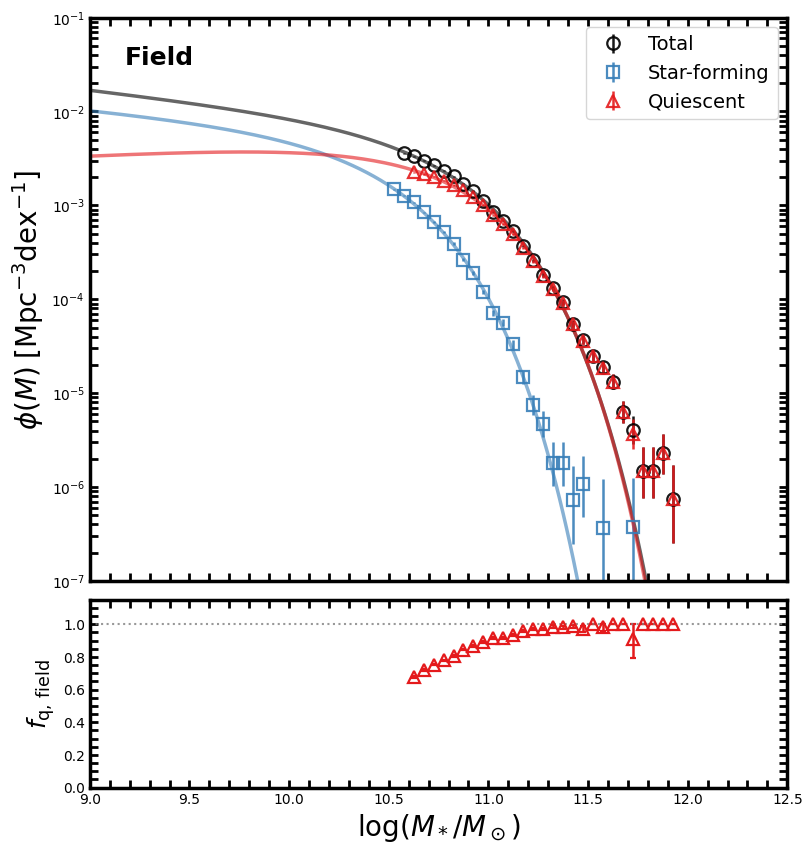

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # assuming your dataframes are pandas

# --- Schechter Function ---
def schechter_1D_SMF(M, phi_0, M_star, alpha):
    return np.log(10) * phi_0 * (10 ** ((1 + alpha) * -(M_star - M))) * np.exp(-10 ** -(M_star - M))

# --- Plot Fit Function (use new DataFrame column names) ---
def plot_fit(ax, df, sample_chain, color, label, marker):
    x = df['logM'].values
    y = df['phi_Mpc-3_dex-1'].values
    yerr = [df['phi_err_low'].values, df['phi_err_up'].values]

    # Median parameter values
    phi_0, M_star, alpha = np.median(sample_chain, axis=0)

    # Data with error bars
    ax.errorbar(
        x, y, yerr=yerr, fmt=marker, markerfacecolor='none',
        markeredgecolor=color, markeredgewidth=1.6, markersize=9,
        linewidth=2, ecolor=color, elinewidth=1.8, alpha=0.9, label=label
    )

    # Best-fit Schechter line
    x_model = np.linspace(9, 12.5, 200)
    y_model = schechter_1D_SMF(x_model, phi_0, M_star, alpha)
    ax.plot(x_model, y_model, color=color, linestyle='-', linewidth=2.5, alpha=0.6)

# --- helpers to fetch counts if present ---
def _get_count_column(df):
    # try a few common names
    for name in ['N', 'count', 'Ngal', 'N_tot', 'N_total', 'N_gal']:
        if name in df.columns:
            return name
    return None

# =========================
# Figure with ratio panel
# =========================
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(9, 10))
gs = GridSpec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.05)

ax_top = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

# --- TOP: SMFs + fits ---
plot_fit(ax_top, field_smf_total,        samples_total, 'black',   'Total',        'o')
plot_fit(ax_top, field_smf_starforming,  samples_sf,    '#377eb8', 'Star-forming', 's')
plot_fit(ax_top, field_smf_quiescent,    samples_q,     '#e41a1c', 'Quiescent',    '^')

# Axis styling (top)
ax_top.set_yscale('log')
ax_top.set_ylabel(r'$\phi(M)\;[\mathrm{Mpc}^{-3}\mathrm{dex}^{-1}]$', fontsize=20)
ax_top.set_xlim(9, 12.5)
ax_top.set_ylim(1e-7, 1e-1)
ax_top.tick_params(axis='both', which='both', direction='in', top=True, right=True,
                   width=2, length=6, labelbottom=False)
ax_top.minorticks_on()
for spine in ax_top.spines.values():
    spine.set_linewidth(2.5)
ax_top.legend(fontsize=14)
ax_top.text(0.05, 0.95, 'Field', transform=ax_top.transAxes,
            fontsize=18, weight='bold', va='top', ha='left', color='black')

# --- BOTTOM: Quiescent fraction (red/black) with BINOMIAL errors ---
# Merge quiescent and total on logM, using new column names
merged = pd.merge(
    field_smf_quiescent[['logM', 'phi_Mpc-3_dex-1', 'phi_err_up', 'phi_err_low'] + ([ _get_count_column(field_smf_quiescent) ] if _get_count_column(field_smf_quiescent) else [])].rename(
        columns={'phi_Mpc-3_dex-1': 'phi_q', 'phi_err_up': 'err_upper_q', 'phi_err_low': 'err_lower_q', (_get_count_column(field_smf_quiescent) or 'no_col'): 'N_q'}
    ),
    field_smf_total[['logM', 'phi_Mpc-3_dex-1', 'phi_err_up', 'phi_err_low'] + ([ _get_count_column(field_smf_total) ] if _get_count_column(field_smf_total) else [])].rename(
        columns={'phi_Mpc-3_dex-1': 'phi_t', 'phi_err_up': 'err_upper_t', 'phi_err_low': 'err_lower_t', (_get_count_column(field_smf_total) or 'no_col'): 'N_t'}
    ),
    on='logM', how='inner'
).dropna(subset=['phi_q', 'phi_t'])

# Compute fq from phi if counts missing; otherwise from counts (they should agree)
eps = np.finfo(float).eps
fq_from_phi = merged['phi_q'] / np.clip(merged['phi_t'], eps, None)

# Prefer counts if present
has_counts_q = 'N_q' in merged.columns and merged['N_q'].notna().all()
has_counts_t = 'N_t' in merged.columns and merged['N_t'].notna().all()
if has_counts_q and has_counts_t:
    Nq = np.asarray(merged['N_q']).astype(float)
    Nt = np.asarray(merged['N_t']).astype(float)
    # Clean impossible values
    Nt = np.clip(Nt, 0, None)
    Nq = np.clip(Nq, 0, Nt)
    fq = np.divide(Nq, np.clip(Nt, 1.0, None))
else:
    # Fallback: estimate Nt from relative uncertainty on total phi (Poisson-like)
    rel_err_t = np.asarray(merged['err_upper_t'] / np.clip(merged['phi_t'], eps, None))
    Nt_eff = 1.0 / np.clip(rel_err_t, eps, None)**2
    fq = fq_from_phi.values
    Nt = Nt_eff  # use effective counts for binomial error

# Binomial 1-sigma
sigma = np.sqrt(np.clip(fq * (1.0 - fq) / np.clip(Nt, 1.0, None), 0.0, None))

# Clip errorbars to [0,1] range (asymmetric yerr)
yerr_low  = np.minimum(sigma, fq)           # cannot go below 0
yerr_high = np.minimum(sigma, 1.0 - fq)     # cannot go above 1

x_q = merged['logM'].values
ax_bottom.errorbar(
    x_q, fq, yerr=[yerr_low, yerr_high],
    fmt='^', color='#e41a1c', markersize=9, markerfacecolor='none',
    markeredgewidth=1.6, linewidth=1.8, capsize=2
)

# Keep the central value inside [0,1] too (defensive)
fq_plot = np.clip(fq, 0.0, 1.0)

# Reference line (optional)
ax_bottom.axhline(1.0, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)

# Axis styling (bottom)
ax_bottom.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=20)
ax_bottom.set_ylabel(r'$f_\mathrm{q,\,field}$', fontsize=18)
ax_bottom.set_xlim([9, 12.5])
ax_bottom.set_ylim([0, 1.15])
ax_bottom.tick_params(axis='both', which='both', direction='in', top=True, right=True,
                      width=2, length=6)
ax_bottom.minorticks_on()
for spine in ax_bottom.spines.values():
    spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()

## $f_q$ Calculation

- **`fq_field_SMF`**: Calculated as the ratio of the SMF data point values.
- **`FieldSMF_fq_Dn4000`**: Computed from the actual number of galaxies in the volume, based on the SMF data. (alsmost same, but to get $f_q$ for incomplete part just calculating this)

This calculation returns the quiescent fraction.

In [18]:
# Collect quiescent fraction measurements and binomial errors into a table
fq_field_local = pd.DataFrame({
    "logM": x_q,                   # bin centers [log(M*/Msun)]
    "f_q": fq,                     # quiescent fraction (central value)
    "f_q_err_low": yerr_low,       # lower 1σ uncertainty
    "f_q_err_high": yerr_high      # upper 1σ uncertainty
})

# Save to CSV (no index) and report where it was written
output_csv = "fq_field_SMF.csv"
# fq_field_local.to_csv(output_csv, index=False)

In [13]:
import numpy as np
import pandas as pd

# Read full SDSS MGS master catalog
df0 = pd.read_csv(f"{MAINPATH}/DATA/FIELD/SDSS_MGS/SDSS_DR18_mgs_mastercat.csv")

# ──────────────────────────────────────────────
# Spectroscopic completeness as a function of r magnitude
# ──────────────────────────────────────────────

# Define r-band apparent-magnitude bins (width 0.25 mag)
mag_edges  = np.arange(5.0, 20.25, 0.25)
mag_centers = 0.5 * (mag_edges[:-1] + mag_edges[1:])  # bin centres

# Assign each galaxy to an r-band magnitude bin
df0["mag_bin"] = pd.cut(
    df0["petroMag_r"],
    bins=mag_edges,
    labels=mag_centers,
    include_lowest=True
)

# Group by magnitude bin
grouped = df0.groupby("mag_bin")

# Total number of objects per bin
total_counts = grouped.size()

# Number of objects with a valid spectroscopic redshift (z != -99) per bin
valid_counts = grouped["z"].apply(lambda z: (z != -99).sum())

# Spectroscopic completeness in each bin
completeness = valid_counts / total_counts

# Avoid infinite weights: replace zero-completeness with NaN
completeness.replace(0, np.nan, inplace=True)

# Map completeness to each galaxy and define spectroscopic weight w_spec = 1 / completeness
df0["w_spec"] = df0["mag_bin"].map(lambda b: 1.0 / completeness.get(b, np.nan))

# Remove temporary bin column
df0.drop(columns="mag_bin", inplace=True)

# ──────────────────────────────────────────────
# Absolute magnitude and field selection
# ──────────────────────────────────────────────

# Extinction-corrected r-band magnitude
df0["petroMag_r_0"] = df0["petroMag_r"] - df0["extinction_r"]

# Absolute r-band magnitude using the cosmology
df0["AbsMag_r"] = df0["petroMag_r_0"] - 5.0 * np.log10(
    cosmo.luminosity_distance(df0["z"]).to("pc").value / 10.0
)

# Field sample: 0.07 < z < 0.11 and valid stellar mass & Dn4000
df = df0[
    (df0["z"] > 0.07) &
    (df0["z"] < 0.11) &
    (df0["M_MASS_CIGALE"] != -99) &
    (df0["Dn4000"] != -99)
].copy()

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_21581/986938148.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df0.groupby("mag_bin")
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/astropy/cosmology/flrw/lambdacdm.py:397: RuntimeWarning: invalid value encountered in sqrt
  return 2 * np.sqrt(x) * hyp2f1(1.0 / 6, 1.0 / 2, 7.0 / 6, -(x**3))
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_21581/986938148.py:52: RuntimeWarning: divide by zero encountered in log10
  df0["AbsMag_r"] = df0["petroMag_r_0"] - 5.0 * np.log10(
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_21581/986938148.py:52: RuntimeWarning: invalid value encountered in log10
  df0["AbsMag_r"] = df0["petroMag_r_0"] - 5.0 * np.log10(


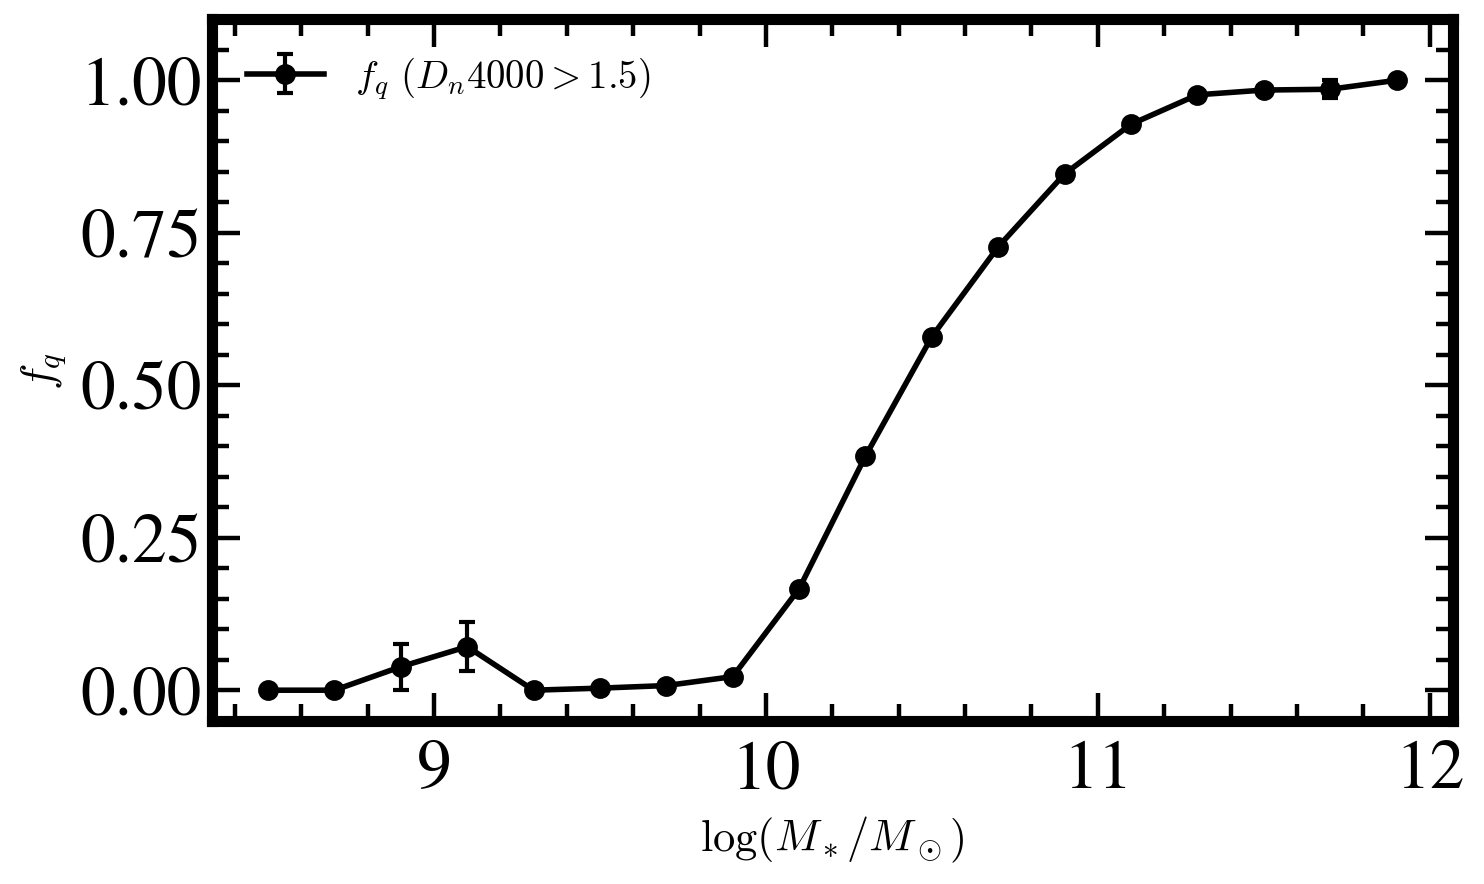

Saved quiescent fraction to 'FieldSMF_fq_Dn4000.csv'


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────
# Quiescent fraction f_q(M_*) via Dn4000 > 1.5
# ──────────────────────────────────────────────

# Mass bins: 7.0 to 13.0 in 0.2-dex steps
mass_edges = np.arange(7.0, 13.2, 0.2)

# Drop rows missing stellar mass or Dn4000
df_valid = df[["M_MASS_CIGALE", "Dn4000"]].dropna().copy()

# Assign each galaxy to a mass bin (left-closed, right-open)
df_valid["mass_bin"] = pd.cut(
    df_valid["M_MASS_CIGALE"],
    bins=mass_edges,
    include_lowest=True,
    right=False,
)

# Count total galaxies and quiescent galaxies (Dn4000 > 1.5) per bin
stats = (
    df_valid
    .assign(is_quiescent=(df_valid["Dn4000"] > 1.5).astype(int))
    .groupby("mass_bin", observed=True)
    .agg(n_total=("is_quiescent", "size"), n_quiescent=("is_quiescent", "sum"))
    .reset_index()
)

# Remove empty bins
stats = stats[stats["n_total"] > 0].copy()

# Quiescent fraction and simple binomial standard error
stats["f_q"]   = stats["n_quiescent"] / stats["n_total"]
stats["stderr"] = np.sqrt(stats["f_q"] * (1.0 - stats["f_q"]) / stats["n_total"])

# Bin centres for the x-axis
stats["logM"] = stats["mass_bin"].apply(lambda iv: 0.5 * (iv.left + iv.right))
stats = stats.sort_values("logM")

# Clip errors to stay within [0, 1]
f_up  = np.minimum(1.0, stats["f_q"] + stats["stderr"])
f_lo  = np.maximum(0.0, stats["f_q"] - stats["stderr"])
yerr  = np.vstack([stats["f_q"] - f_lo, f_up - stats["f_q"]])

# ──────────────────────────────────────────────
# Plot
# ──────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    stats["logM"].to_numpy(),
    stats["f_q"].to_numpy(),
    yerr=yerr,
    fmt="o-", color="black",
    ms=6, mew=1.5,
    elinewidth=1.5, capsize=3,
    label=r"$f_q\ (D_n4000 > 1.5)$",
)

ax.set_xlabel(r"$\log(M_*/M_\odot)$", fontsize=16)
ax.set_ylabel(r"$f_q$",               fontsize=16)
ax.set_ylim(-0.05, 1.1)
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax.minorticks_on()
ax.legend(fontsize=14, frameon=False)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Save quiescent fraction table
# ──────────────────────────────────────────────

fq_output = pd.DataFrame({
    "logM":         stats["logM"].to_numpy(),
    "f_q":          stats["f_q"].to_numpy(),
    "f_q_err_low":  (stats["f_q"] - f_lo).to_numpy(),
    "f_q_err_high": (f_up - stats["f_q"]).to_numpy(),
})

output_csv = "FieldSMF_fq_Dn4000.csv"
fq_output.to_csv(output_csv, index=False, float_format="%.5g")
print(f"Saved quiescent fraction to '{output_csv}'")